# Xenofobia en redes sociales durante la pandemia de COVID-19 en Argentina
## Analisis vinculado al DNU 70/10 y/o a extranjeros

## Análisis para artículo en Revista PERIPLOS

**Autora:** Natalia De Bandi  
**Fecha:** Marzo 2026  



## 1. Origen del dataset

### Fuente: Proyecto PIUBAMAS / HuggingFace

El dataset utilizado es `tweets_medios_arg.csv`, generado a partir del conjunto de datos público disponible en HuggingFace:

> **Dataset:** [`piubamas/articles_and_comments`](https://huggingface.co/datasets/piubamas/articles_and_comments)  
> **Proyecto:** PIUBAMAS (Programación UBA - Minería y Análisis de Sentimientos en Arabe y Español)

El dataset se encuentra etiquetado sobre discursos discriminatorios y de odio con este etiquetador:

> **Clasificador:** [`piuba-bigdata/beto-contextualized-hate-speech`](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech)

Las categorías de odio etiquetadas son:
| Etiqueta | Descripción |
|----------|-------------|
| `CALLS` | Llamados a la acción violenta |
| `WOMEN` | Odio hacia mujeres |
| `LGBTI` | Odio hacia personas LGBTI+ |
| `RACISM` | Racismo / xenofobia |
| `CLASS` | Odio por clase social |
| `POLITICS` | Odio político |
| `DISABLED` | Odio hacia personas con discapacidad |
| `APPEARANCE` | Odio por apariencia física |
| `CRIMINAL` | Estigmatización criminal |



Los medios argentinos incluidos son:

| Usuario Twitter | Medio |
|-----------------|-------|
| `clarincom` | Clarín |
| `LANACION` | La Nación |
| `infobae` | Infobae |
| `pagina12` | Página 12 |
| `perfilcom` | Perfil |
| `cronica` | Crónica |
| `izquierdadiario` | La Izquierda Diario |
| `laderechadiario` | La Derecha Diario |
| `laderechamedios` | La Derecha Medios |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 2. Carga del dataset

In [2]:
df = pd.read_csv('data/tweets_medios_arg.csv', parse_dates=['date_tweet'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 5,493,397 filas × 18 columnas


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:03:00.900,@clarincom A mi me preocupa el trabajo.. La ev...,1532596098,0,0,0,0,0,0,0,0,0,0
1,1,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:05:04.500,@clarincom Lo que preocupa. https://t.co/Vmf9V...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
2,2,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:06:03.100,@clarincom Lo que les preocupa. https://t.co/P...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
3,3,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:11:02.300,@clarincom Le recomendaríamos al presidente de...,582286194,0,0,0,0,0,0,0,0,0,0
4,4,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:26:00.600,@clarincom Para salvar al correo de la quiebra...,951552761988034560,0,0,0,0,0,0,0,0,0,0


## 3. Descripción del dataset

### 3.1 Estructura de columnas

In [3]:
# Descripción de columnas y tipos de datos
col_desc = {
    'id': 'Índice del comentario dentro de la noticia',
    'tweet_id_noticia': 'ID del tweet de la noticia a la que responde el comentario',
    'title': 'Título de la noticia',
    'resumen': 'Texto del tweet de la noticia (resumen)',
    'medio': 'Cuenta de Twitter del medio de comunicación',
    'date_tweet': 'Fecha y hora del comentario (UTC)',
    'text': 'Texto del comentario',
    'user_id': 'ID del usuario que publicó el comentario',
    'HATEFUL': 'Indicador agregado: 1 si el comentario fue clasificado como odioso en alguna categoría',
    'CALLS': 'Llamados a la violencia',
    'WOMEN': 'Odio hacia mujeres',
    'LGBTI': 'Odio hacia LGBTI+',
    'RACISM': 'Racismo / xenofobia',
    'CLASS': 'Odio por clase social',
    'POLITICS': 'Odio político',
    'DISABLED': 'Odio hacia personas con discapacidad',
    'APPEARANCE': 'Odio por apariencia física',
    'CRIMINAL': 'Estigmatización criminal',
}

desc_df = pd.DataFrame({
    'Columna': col_desc.keys(),
    'Descripción': col_desc.values(),
    'Tipo': [df[c].dtype for c in col_desc.keys()]
})
display(desc_df)

,Columna,Descripción,Tipo
0,id,Índice del comentario dentro de la noticia,int64
1,tweet_id_noticia,ID del tweet de la noticia a la que responde e...,int64
2,title,Título de la noticia,str
3,resumen,Texto del tweet de la noticia (resumen),str
4,medio,Cuenta de Twitter del medio de comunicación,str
5,date_tweet,Fecha y hora del comentario (UTC),datetime64[us]
6,text,Texto del comentario,str
7,user_id,ID del usuario que publicó el comentario,int64
8,HATEFUL,Indicador agregado: 1 si el comentario fue cla...,int64
9,CALLS,Llamados a la violencia,int64


### 3.2 Estadísticas generales

In [4]:
print("=" * 55)
print("ESTADÍSTICAS GENERALES DEL DATASET")
print("=" * 55)
print(f"  Total de comentarios:      {len(df):>12,}")
print(f"  Comentarios odiosos:       {df['HATEFUL'].sum():>12,}  ({df['HATEFUL'].mean()*100:.1f}%)")
print(f"  Comentarios no odiosos:    {(df['HATEFUL']==0).sum():>12,}  ({(df['HATEFUL']==0).mean()*100:.1f}%)")
print(f"  Rango temporal:            {df['date_tweet'].min().date()} → {df['date_tweet'].max().date()}")
print(f"  Medios cubiertos:          {df['medio'].nunique():>12,}")
print(f"  Noticias únicas:           {df['tweet_id_noticia'].nunique():>12,}")
print(f"  Usuarios únicos:           {df['user_id'].nunique():>12,}")

ESTADÍSTICAS GENERALES DEL DATASET
  Total de comentarios:         5,493,397
  Comentarios odiosos:            340,593  (6.2%)
  Comentarios no odiosos:       5,152,804  (93.8%)
  Rango temporal:            2020-02-10 → 2021-06-25
  Medios cubiertos:                     9
  Noticias únicas:                330,600
  Usuarios únicos:                402,870


### 3.3 Distribución por medio de comunicación

In [5]:
medios_stats = df.groupby('medio').agg(
    comentarios=('text', 'count'),
    odiosos=('HATEFUL', 'sum'),
    noticias=('tweet_id_noticia', 'nunique'),
    primer_tweet=('date_tweet', 'min'),
    ultimo_tweet=('date_tweet', 'max')
).sort_values('comentarios', ascending=False)

medios_stats['% odio'] = (medios_stats['odiosos'] / medios_stats['comentarios'] * 100).round(2)
medios_stats['primer_tweet'] = medios_stats['primer_tweet'].dt.date
medios_stats['ultimo_tweet'] = medios_stats['ultimo_tweet'].dt.date

display(medios_stats[['comentarios', 'noticias', 'odiosos', '% odio', 'primer_tweet', 'ultimo_tweet']])

,comentarios,noticias,odiosos,% odio,primer_tweet,ultimo_tweet
medio,,,,,,
infobae,1691830,98751,105128,6.21,2020-02-10,2021-06-25
LANACION,1574297,51536,94459,6.00,2020-02-10,2021-06-25
clarincom,1486018,66267,96918,6.52,2020-02-10,2021-06-25
pagina12,221971,29184,10242,4.61,2020-02-13,2021-06-25
cronica,205588,50316,15371,7.48,2020-02-10,2021-06-24
perfilcom,159860,21056,7237,4.53,2020-02-10,2021-06-25
laderechamedios,69944,2800,4726,6.76,2020-07-14,2021-02-26
laderechadiario,65907,2904,4869,7.39,2020-02-11,2021-06-24
izquierdadiario,17982,7786,1643,9.14,2020-03-06,2021-06-22


### 3.4 Cobertura temporal del dataset

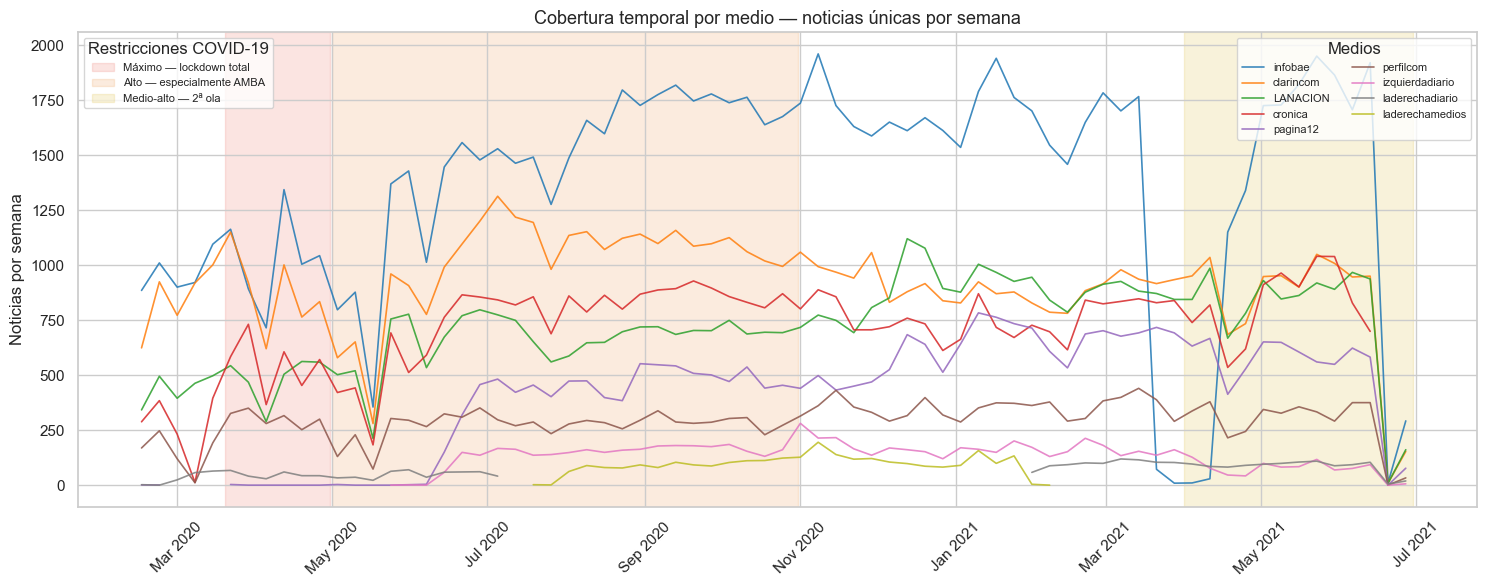

In [6]:
import matplotlib.dates as mdates

# --- Noticias únicas por SEMANA y por medio ---
df_noticias = df.drop_duplicates(subset=['tweet_id_noticia', 'medio']).copy()

noticias_semanales = (
    df_noticias
    .groupby(['medio', pd.Grouper(key='date_tweet', freq='W')])['tweet_id_noticia']
    .count()
    .unstack('medio')
)

# Rango completo semanal → NaN donde no hay datos (rompe la línea)
semana_rango = pd.date_range(noticias_semanales.index.min(), noticias_semanales.index.max(), freq='W')
noticias_semanales = noticias_semanales.reindex(semana_rango)

# Reemplazar 0 por NaN también (semanas con cero noticias = hueco)
noticias_semanales = noticias_semanales.replace(0, float('nan'))

# Orden por volumen total
orden_medios = noticias_semanales.sum().sort_values(ascending=False).index.tolist()

# --- Períodos de restricciones ---
periodos = [
    (pd.Timestamp('2020-03-20'), pd.Timestamp('2020-04-30'), '#e74c3c', 'Máximo — lockdown total'),
    (pd.Timestamp('2020-05-01'), pd.Timestamp('2020-10-31'), '#e67e22', 'Alto — especialmente AMBA'),
    (pd.Timestamp('2021-04-01'), pd.Timestamp('2021-06-30'), '#d4ac0d', 'Medio-alto — 2ª ola'),
]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 6))

# Franjas de pandemia (fondo)
franja_handles = []
for inicio, fin, color, label in periodos:
    patch = ax.axvspan(inicio, fin, alpha=0.15, color=color, zorder=0, label=label)
    franja_handles.append(patch)

# Líneas por medio
colores = plt.cm.tab10.colors
linea_handles = []
for i, medio in enumerate(orden_medios):
    serie = noticias_semanales[medio]
    linea, = ax.plot(serie.index, serie.values,
                     label=medio, color=colores[i % len(colores)],
                     linewidth=1.2, alpha=0.85)
    linea_handles.append(linea)

# Ejes y formato
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('Noticias por semana')
ax.set_title('Cobertura temporal por medio — noticias únicas por semana', fontsize=13)

# Dos leyendas separadas
ley_medios = ax.legend(handles=linea_handles, loc='upper right', fontsize=8,
                       title='Medios', ncol=2)
ax.add_artist(ley_medios)
ax.legend(handles=franja_handles, loc='upper left', fontsize=8,
          title='Restricciones COVID-19')

plt.tight_layout()
plt.savefig('outputs/cobertura_temporal_medios.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import html as htmllib
from IPython.display import display, HTML

# ── Selección de noticia representativa (top en comentarios RACISM) ──────────
candidatas = (
    df[df['RACISM'] == 1]
    .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .size()
    .reset_index(name='n_racism')
    .query('n_racism >= 5')
    .sort_values('n_racism', ascending=False)
)

# Índice 2 para tener variedad (cambiar por 0, 1, 3... para ver otras noticias)
row = candidatas.iloc[2]
tweet_id  = row['tweet_id_noticia']
medio     = row['medio']
titulo    = htmllib.escape(str(row['title']))
resumen   = htmllib.escape(str(row['resumen'])[:300])

todos = df[df['tweet_id_noticia'] == tweet_id].copy()
fecha_str         = todos['date_tweet'].min().strftime('%d %b %Y')
total_comentarios = len(todos)
n_racism          = row['n_racism']

# 4 comentarios con RACISM=1
odiosos = todos[todos['RACISM'] == 1].head(4)

url_tweet = f"https://twitter.com/{medio}/status/{tweet_id}"

# ── Badges de categorías ─────────────────────────────────────────────────────
CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia / Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Odio por clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio político'),
    'DISABLED':   ('#2471a3', 'Odio a discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Odio por apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges(c_row):
    badges = ''
    for col, (color, label) in CATEGORIAS.items():
        if c_row.get(col, 0) == 1:
            badges += (f'<span style="background:{color};color:white;'
                       f'padding:2px 8px;border-radius:10px;font-size:11px;'
                       f'margin-right:4px;">{label}</span>')
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

# ── Nombres legibles de medios ────────────────────────────────────────────────
NOMBRES = {
    'clarincom': 'Clarín', 'LANACION': 'La Nación', 'infobae': 'Infobae',
    'pagina12': 'Página 12', 'cronica': 'Crónica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}
nombre_medio = NOMBRES.get(medio, medio)

# ── Bloque de comentarios ─────────────────────────────────────────────────────
comentarios_html = ''
for _, c in odiosos.iterrows():
    texto  = htmllib.escape(str(c['text'])[:280])
    fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
    comentarios_html += f"""
    <div style="margin:10px 0 10px 36px; padding:12px 15px; background:#fff;
                border-left:3px solid #e74c3c; border-radius:6px;
                box-shadow:0 1px 3px rgba(0,0,0,0.08);">
      <div style="font-size:12px; color:#888; margin-bottom:6px;">
        💬 Usuario anónimo · {fecha_c}
      </div>
      <div style="font-size:14px; color:#222; line-height:1.6;">
        {texto}
      </div>
      <div style="margin-top:8px;">
        {make_badges(c)}
      </div>
    </div>"""

# ── HTML final ────────────────────────────────────────────────────────────────
html = f"""
<div style="font-family:'Segoe UI',Arial,sans-serif; max-width:700px; margin:20px auto;">

  <!-- Encabezado explicativo -->
  <div style="background:#e8f4fd; border-radius:8px; padding:10px 16px;
              margin-bottom:16px; font-size:13px; color:#2471a3; line-height:1.6;">
    <strong>Estructura del dataset</strong><br>
    Cada fila representa un <em>comentario</em> asociado a una <em>noticia</em> publicada
    por un medio en Twitter/X. Esta noticia recibió
    <strong>{total_comentarios:,} comentarios</strong>,
    de los cuales <strong>{n_racism} fueron clasificados como xenofobia/racismo</strong>.
    Se muestran 4 a modo de ejemplo.
  </div>

  <!-- Tweet del medio (noticia) -->
  <div style="background:#f7f9fa; border:1px solid #dce1e7; border-radius:12px;
              padding:18px 20px;">

    <!-- Cabecera usuario -->
    <div style="display:flex; align-items:center; margin-bottom:12px;">
      <div style="width:42px; height:42px; background:#1da1f2; border-radius:50%;
                  display:flex; align-items:center; justify-content:center;
                  color:white; font-weight:bold; font-size:17px; margin-right:12px;
                  flex-shrink:0;">
        {nombre_medio[0]}
      </div>
      <div>
        <div style="font-weight:700; font-size:14px; color:#14171a;">{nombre_medio}</div>
        <div style="font-size:12px; color:#657786;">@{medio} · {fecha_str}</div>
      </div>
      <div style="margin-left:auto;">
        <span style="background:#1da1f2; color:white; font-size:11px;
                     padding:3px 9px; border-radius:12px;">NOTICIA</span>
      </div>
    </div>

    <!-- Texto del tweet -->
    <div style="font-size:15px; color:#14171a; line-height:1.65; margin-bottom:12px;">
      {resumen}
    </div>

    <!-- Card título noticia -->
    <div style="border:1px solid #dce1e7; border-radius:10px; padding:12px 15px;
                background:white; margin-bottom:12px;">
      <div style="font-size:10px; color:#aaa; text-transform:uppercase;
                  letter-spacing:.5px; margin-bottom:5px;">Título</div>
      <div style="font-size:14px; font-weight:600; color:#14171a; line-height:1.45;">
        {titulo}
      </div>
    </div>

    <!-- Enlace -->
    <div style="font-size:13px;">
      <a href="{url_tweet}" target="_blank"
         style="color:#1da1f2; text-decoration:none;">
        🔗 Ver tweet original en Twitter/X →
      </a>
    </div>
  </div>

  <!-- Separador de hilo -->
  <div style="margin:8px 0 4px 18px; color:#aaa; font-size:12px;">
    ↳ {total_comentarios:,} respuestas en total —
    mostrando {len(odiosos)} clasificadas como xenofobia/racismo
  </div>

  <!-- Comentarios -->
  {comentarios_html}

</div>
"""

display(HTML(html))


## 4. Análisis del dataset filtrado por palabras clave DNU

Subconjunto del dataset principal que filtra filas cuya noticia o comentario menciona palabras clave vinculadas al DNU 70/2017 y/o a migraciones/extranjeros.

### 4.1 Carga del dataset filtrado

In [8]:
dnu_df = pd.read_csv('data/piubamas_dnu_v2.csv', parse_dates=['date_tweet'])

print(f"Dataset DNU cargado: {dnu_df.shape[0]:,} filas x {dnu_df.shape[1]} columnas")
print(f"Rango temporal:      {dnu_df['date_tweet'].min().date()} a {dnu_df['date_tweet'].max().date()}")
print(f"Noticias unicas:     {dnu_df['tweet_id_noticia'].nunique():,}")
print(f"Comentarios odiosos: {dnu_df['HATEFUL'].sum():,} ({dnu_df['HATEFUL'].mean()*100:.1f}%)")
dnu_df.head(3)


Dataset DNU cargado: 1,056,507 filas x 18 columnas
Rango temporal:      2020-02-10 a 2021-06-25
Noticias unicas:     99,775
Comentarios odiosos: 59,674 (5.6%)


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:03:00.900,@clarincom A mi me preocupa el trabajo.. La ev...,1532596098,0,0,0,0,0,0,0,0,0,0
1,1,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:05:04.500,@clarincom Lo que preocupa. https://t.co/Vmf9V...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
2,2,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:06:03.100,@clarincom Lo que les preocupa. https://t.co/P...,1222094021687943168,0,0,0,0,0,0,0,0,0,0


### 4.2 Notas y comentarios por diario

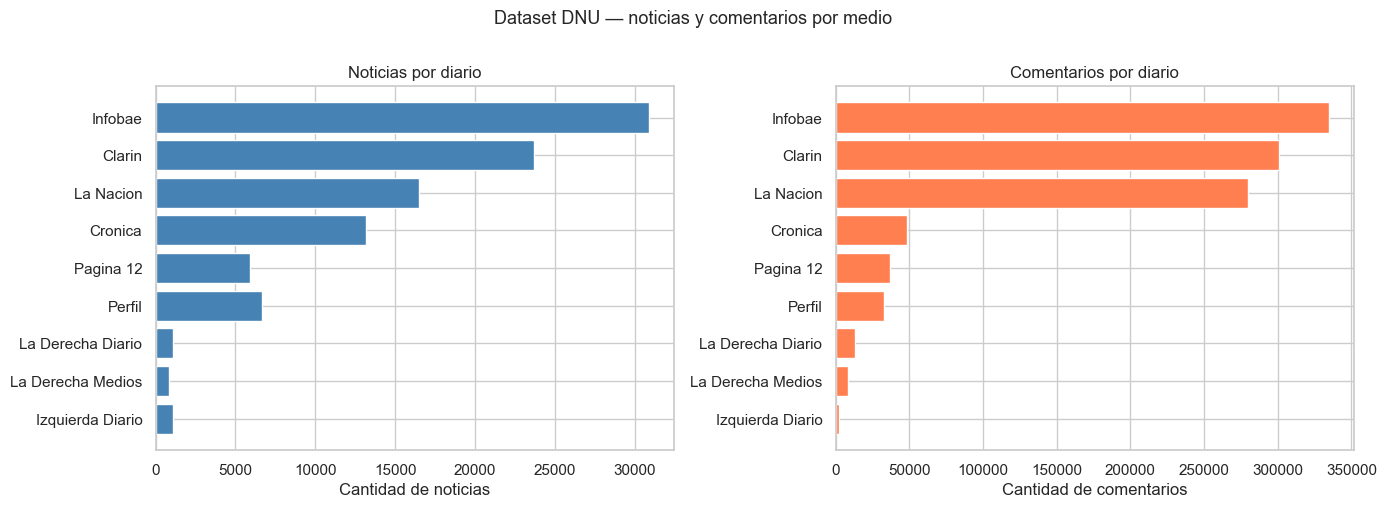

,noticias,comentarios,odiosos,% odio
medio,,,,
infobae,30869,334801,18799,5.61
clarincom,23676,300900,17687,5.88
LANACION,16510,279580,15752,5.63
cronica,13178,48141,2590,5.38
pagina12,5880,36897,1740,4.72
perfilcom,6629,32926,1227,3.73
laderechadiario,1089,12878,1028,7.98
laderechamedios,845,8080,649,8.03
izquierdadiario,1099,2304,202,8.77


In [9]:
NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

dnu_medios = dnu_df.groupby('medio').agg(
    comentarios=('text', 'count'),
    noticias=('tweet_id_noticia', 'nunique'),
    odiosos=('HATEFUL', 'sum'),
).sort_values('comentarios', ascending=False)
dnu_medios['pct_odio'] = (dnu_medios['odiosos'] / dnu_medios['comentarios'] * 100).round(2)

nombres = [NOMBRES.get(m, m) for m in dnu_medios.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(nombres[::-1], dnu_medios['noticias'].values[::-1], color='steelblue')
axes[0].set_title('Noticias por diario')
axes[0].set_xlabel('Cantidad de noticias')
axes[1].barh(nombres[::-1], dnu_medios['comentarios'].values[::-1], color='coral')
axes[1].set_title('Comentarios por diario')
axes[1].set_xlabel('Cantidad de comentarios')
fig.suptitle('Dataset DNU — noticias y comentarios por medio', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/dnu_kw_medios.png', dpi=150, bbox_inches='tight')
plt.show()

display(dnu_medios.rename(columns={'pct_odio': '% odio'})[['noticias', 'comentarios', 'odiosos', '% odio']])


### 4.3 Serie temporal — noticias por semana

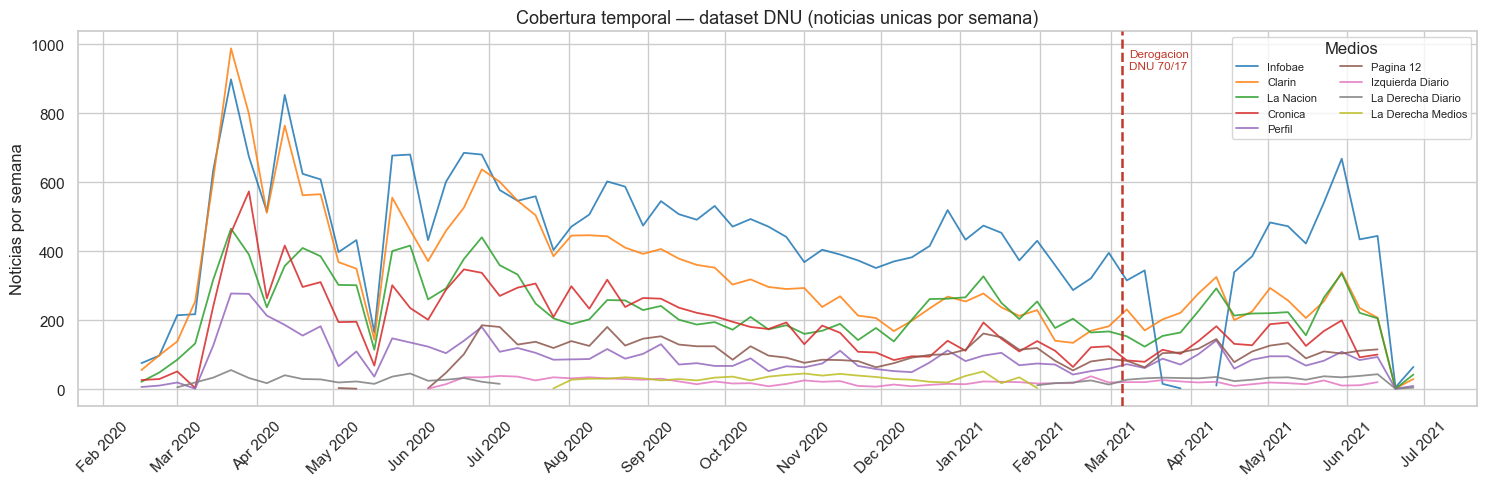

In [10]:
import matplotlib.dates as mdates

dnu_unicas = dnu_df.drop_duplicates(subset=['tweet_id_noticia', 'medio']).copy()
noticias_sem = (
    dnu_unicas
    .groupby(['medio', pd.Grouper(key='date_tweet', freq='W')])['tweet_id_noticia']
    .count()
    .unstack('medio')
)
sem_rango = pd.date_range(noticias_sem.index.min(), noticias_sem.index.max(), freq='W')
noticias_sem = noticias_sem.reindex(sem_rango).replace(0, float('nan'))
orden = noticias_sem.sum().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
colores = plt.cm.tab10.colors
linea_handles = []
for i, medio in enumerate(orden):
    serie = noticias_sem[medio]
    linea, = ax.plot(serie.index, serie.values,
                     label=NOMBRES.get(medio, medio),
                     color=colores[i % len(colores)],
                     linewidth=1.3, alpha=0.85)
    linea_handles.append(linea)

# Marcar derogacion DNU 70/17
ax.axvline(pd.Timestamp('2021-03-05'), color='#c0392b', linewidth=1.8,
           linestyle='--', zorder=5)
ylim = ax.get_ylim()
ax.text(pd.Timestamp('2021-03-08'), ylim[1] * 0.95,
        'Derogacion\nDNU 70/17', color='#c0392b', fontsize=8.5, va='top')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.set_ylabel('Noticias por semana')
ax.set_title('Cobertura temporal — dataset DNU (noticias unicas por semana)', fontsize=13)
ax.legend(handles=linea_handles, loc='upper right', fontsize=8, ncol=2, title='Medios')
plt.tight_layout()
plt.savefig('outputs/dnu_kw_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Ejemplo de nota — 5 de marzo de 2021

Dia de la derogacion del DNU 70/2017 (decreto de Macri sobre migraciones). El dataset cubre 2020–2021; no hay datos de fechas posteriores.

In [11]:
import html as htmllib
from IPython.display import display, HTML

FECHA_EJEMPLO = '2021-03-05'

mask_fecha = dnu_df['date_tweet'].dt.date == pd.Timestamp(FECHA_EJEMPLO).date()
mask_kw    = dnu_df['title'].str.contains('DNU|Macri|migrac|extranjero', na=False, case=False)
candidatas = (
    dnu_df[mask_fecha & mask_kw]
    .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .size()
    .reset_index(name='n_comentarios')
    .sort_values('n_comentarios', ascending=False)
    .reset_index(drop=True)
)

print(f'{len(candidatas)} noticias sobre DNU el {FECHA_EJEMPLO}:')
display(candidatas[['medio', 'n_comentarios', 'title']].head(5))

row      = candidatas.iloc[0]
tweet_id = row['tweet_id_noticia']
medio    = row['medio']
titulo   = htmllib.escape(str(row['title']))
resumen  = htmllib.escape(str(row['resumen'])[:300])

todos             = dnu_df[dnu_df['tweet_id_noticia'] == tweet_id].copy()
fecha_str         = todos['date_tweet'].min().strftime('%d %b %Y')
total_comentarios = len(todos)
nombre_medio      = NOMBRES.get(medio, medio)
url_tweet         = f'https://twitter.com/{medio}/status/{tweet_id}'

odiosos = todos[todos['HATEFUL'] == 1].head(4)
if len(odiosos) == 0:
    odiosos = todos.head(4)

CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia / Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Odio por clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio politico'),
    'DISABLED':   ('#2471a3', 'Odio a discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Odio por apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges(c_row):
    badges = ''
    for col, (color, label) in CATEGORIAS.items():
        if c_row.get(col, 0) == 1:
            badges += (f'<span style="background:{color};color:white;'
                       f'padding:2px 8px;border-radius:10px;font-size:11px;'
                       f'margin-right:4px;">{label}</span>')
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

comentarios_html = ''
for _, c in odiosos.iterrows():
    texto   = htmllib.escape(str(c['text'])[:280])
    fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
    comentarios_html += (
        f'<div style="margin:10px 0 10px 36px;padding:12px 15px;background:#fff;'
        f'border-left:3px solid #e74c3c;border-radius:6px;'
        f'box-shadow:0 1px 3px rgba(0,0,0,0.08);">'
        f'<div style="font-size:12px;color:#888;margin-bottom:6px;">'
        f'Comentario &middot; {fecha_c}</div>'
        f'<div style="font-size:14px;color:#222;line-height:1.6;">{texto}</div>'
        f'<div style="margin-top:8px;">{make_badges(c)}</div>'
        f'</div>'
    )

html_out = (
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:700px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-radius:8px;padding:10px 16px;'
    f'margin-bottom:16px;font-size:13px;color:#c0392b;line-height:1.6;">'
    f'<strong>Dataset filtrado DNU</strong><br>'
    f'Noticia del <strong>{FECHA_EJEMPLO}</strong> con <strong>{total_comentarios:,} comentarios</strong>. '
    f'Se muestran hasta 4 clasificados como odiosos.</div>'
    f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:18px 20px;">'
    f'<div style="display:flex;align-items:center;margin-bottom:12px;">'
    f'<div style="width:42px;height:42px;background:#1da1f2;border-radius:50%;'
    f'display:flex;align-items:center;justify-content:center;'
    f'color:white;font-weight:bold;font-size:17px;margin-right:12px;flex-shrink:0;">{nombre_medio[0]}</div>'
    f'<div><div style="font-weight:700;font-size:14px;color:#14171a;">{nombre_medio}</div>'
    f'<div style="font-size:12px;color:#657786;">@{medio} &middot; {fecha_str}</div></div>'
    f'<div style="margin-left:auto;">'
    f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 9px;border-radius:12px;">NOTICIA</span>'
    f'</div></div>'
    f'<div style="font-size:15px;color:#14171a;line-height:1.65;margin-bottom:12px;">{resumen}</div>'
    f'<div style="border:1px solid #dce1e7;border-radius:10px;padding:12px 15px;'
    f'background:white;margin-bottom:12px;">'
    f'<div style="font-size:10px;color:#aaa;text-transform:uppercase;letter-spacing:.5px;margin-bottom:5px;">Titulo</div>'
    f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.45;">{titulo}</div></div>'
    f'<div style="font-size:13px;">'
    f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;text-decoration:none;">'
    f'Ver tweet original en Twitter/X</a></div></div>'
    f'<div style="margin:8px 0 4px 18px;color:#aaa;font-size:12px;">'
    f'{total_comentarios:,} comentarios en total &mdash; mostrando {len(odiosos)} clasificados como odiosos</div>'
    f'{comentarios_html}</div>'
)

display(HTML(html_out))


12 noticias sobre DNU el 2021-03-05:


,medio,n_comentarios,title
0,clarincom,710,El Gobierno derogó el decreto de Mauricio Macr...
1,infobae,609,El Gobierno derogó el decreto de Macri que imp...
2,LANACION,137,Ley de Migraciones: el Gobierno derogó el decr...
3,infobae,105,El Gobierno derogó el decreto de Macri que imp...
4,infobae,38,El Gobierno derogó el decreto de Macri que imp...


### 4.5 Proporción de odio a lo largo del tiempo

Evolución semanal de la tasa de comentarios HATEFUL en el dataset completo y en el subconjunto filtrado por palabras clave DNU, sin distinguir por medio.

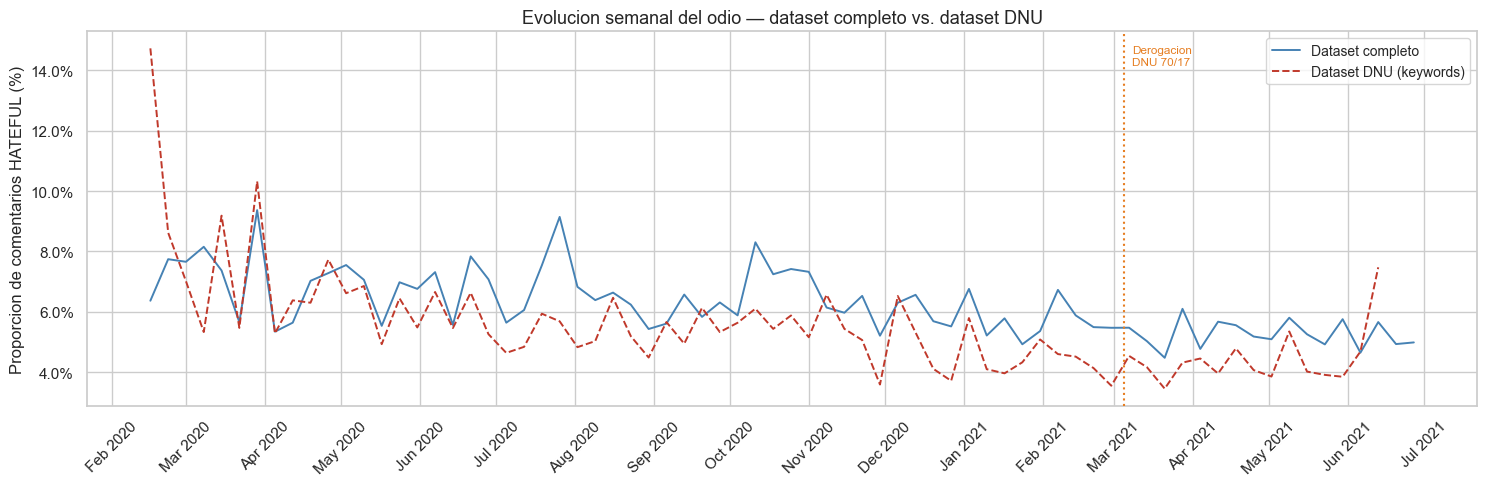

Tasa media de odio — dataset completo: 6.23%
Tasa media de odio — dataset DNU:      5.48%


In [12]:
import matplotlib.dates as mdates

FREQ = 'W'

# --- Proporción semanal de odio en cada dataset ---
def hate_rate_serie(dataframe, freq=FREQ):
    return (
        dataframe
        .set_index('date_tweet')
        .resample(freq)['HATEFUL']
        .agg(hate_rate='mean', n='count')
    )

ts_full = hate_rate_serie(df)
ts_dnu  = hate_rate_serie(dnu_df)

# Filtrar semanas con muy pocos comentarios (ruido)
MIN_COMENTARIOS = 100
ts_full['hate_rate'] = ts_full['hate_rate'].where(ts_full['n'] >= MIN_COMENTARIOS)
ts_dnu['hate_rate']  = ts_dnu['hate_rate'].where(ts_dnu['n'] >= MIN_COMENTARIOS)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(ts_full.index, ts_full['hate_rate'] * 100,
        color='steelblue', linewidth=1.4, label='Dataset completo')
ax.plot(ts_dnu.index,  ts_dnu['hate_rate'] * 100,
        color='#c0392b', linewidth=1.4, linestyle='--', label='Dataset DNU (keywords)')

# Marcar derogacion DNU 70/17
ax.axvline(pd.Timestamp('2021-03-05'), color='#e67e22', linewidth=1.5,
           linestyle=':', zorder=5)
ax.text(pd.Timestamp('2021-03-08'), ax.get_ylim()[1] * 0.97,
        'Derogacion\nDNU 70/17', color='#e67e22', fontsize=8.5, va='top')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.set_ylabel('Proporcion de comentarios HATEFUL (%)')
ax.set_title('Evolucion semanal del odio — dataset completo vs. dataset DNU', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/hate_rate_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Tasa media de odio — dataset completo: {ts_full['hate_rate'].mean()*100:.2f}%")
print(f"Tasa media de odio — dataset DNU:      {ts_dnu['hate_rate'].mean()*100:.2f}%")


### 4.5 B Proporción de comentarios RACISM a lo largo del tiempo

Evolución semanal de la tasa de comentarios clasificados como **RACISM** (xenofobia / racismo) en el dataset completo y en el subconjunto filtrado por palabras clave DNU, sin distinguir por medio.

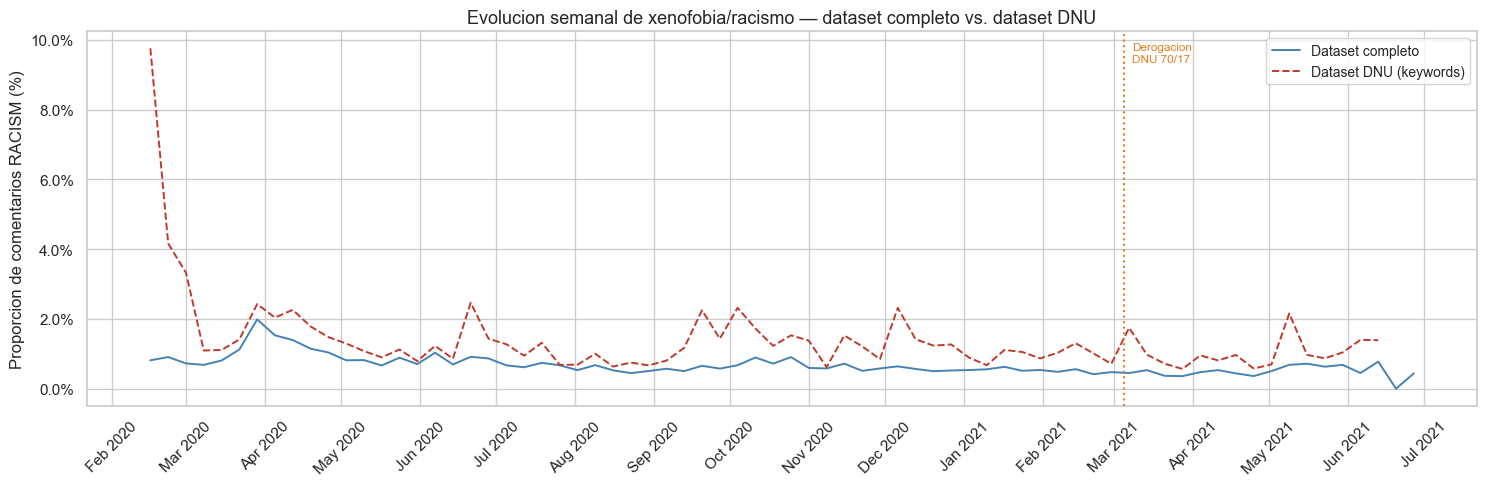

Tasa media de RACISM — dataset completo: 0.68%
Tasa media de RACISM — dataset DNU:      1.40%


In [13]:
import matplotlib.dates as mdates

FREQ = 'W'

# --- Proporción semanal de RACISM en cada dataset ---
def racism_rate_serie(dataframe, freq=FREQ):
    return (
        dataframe
        .set_index('date_tweet')
        .resample(freq)['RACISM']
        .agg(racism_rate='mean', n='count')
    )

ts_full_r = racism_rate_serie(df)
ts_dnu_r  = racism_rate_serie(dnu_df)

# Filtrar semanas con muy pocos comentarios (ruido)
MIN_COMENTARIOS = 100
ts_full_r['racism_rate'] = ts_full_r['racism_rate'].where(ts_full_r['n'] >= MIN_COMENTARIOS)
ts_dnu_r['racism_rate']  = ts_dnu_r['racism_rate'].where(ts_dnu_r['n'] >= MIN_COMENTARIOS)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(ts_full_r.index, ts_full_r['racism_rate'] * 100,
        color='steelblue', linewidth=1.4, label='Dataset completo')
ax.plot(ts_dnu_r.index,  ts_dnu_r['racism_rate'] * 100,
        color='#c0392b', linewidth=1.4, linestyle='--', label='Dataset DNU (keywords)')

# Marcar derogacion DNU 70/17
ax.axvline(pd.Timestamp('2021-03-05'), color='#e67e22', linewidth=1.5,
           linestyle=':', zorder=5)
ax.text(pd.Timestamp('2021-03-08'), ax.get_ylim()[1] * 0.97,
        'Derogacion\nDNU 70/17', color='#e67e22', fontsize=8.5, va='top')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.set_ylabel('Proporcion de comentarios RACISM (%)')
ax.set_title('Evolucion semanal de xenofobia/racismo — dataset completo vs. dataset DNU', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/racism_rate_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Tasa media de RACISM — dataset completo: {ts_full_r['racism_rate'].mean()*100:.2f}%")
print(f"Tasa media de RACISM — dataset DNU:      {ts_dnu_r['racism_rate'].mean()*100:.2f}%")

### 4.6 Dia pico de odio — detalle de notas y comentarios


In [14]:
import html as htmllib
from IPython.display import display, HTML
import random

# --- Identificar el dia pico automaticamente ---
ts_diario = (
    dnu_df.set_index('date_tweet')
    .resample('D')['HATEFUL']
    .agg(hate_rate='mean', n='count')
)
ts_diario = ts_diario[ts_diario['n'] >= 30]
dia_pico = ts_diario['hate_rate'].idxmax().date()
hate_pct = ts_diario['hate_rate'].max() * 100
print(f'Dia pico: {dia_pico} | tasa de odio: {hate_pct:.1f}%')

# --- Notas del dia pico, ordenadas por comentarios odiosos ---
mask_dia = dnu_df['date_tweet'].dt.date == dia_pico
dia_df = dnu_df[mask_dia].copy()

notas_dia = (
    dia_df.groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .agg(n_total=('text', 'count'), n_odio=('HATEFUL', 'sum'))
    .reset_index()
    .sort_values('n_odio', ascending=False)
    .head(2)
    .reset_index(drop=True)
)

print(f'Total comentarios ese dia: {len(dia_df)} | Odiosos: {dia_df["HATEFUL"].sum()}')
display(notas_dia[['medio', 'n_total', 'n_odio', 'title']])

# --- HTML helpers ---
CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia/Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio politico'),
    'DISABLED':   ('#2471a3', 'Discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}
NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

def make_badges(c_row):
    badges = ''.join(
        f'<span style="background:{color};color:white;padding:2px 7px;border-radius:10px;'
        f'font-size:11px;margin-right:3px;">{label}</span>'
        for col, (color, label) in CATEGORIAS.items() if c_row.get(col, 0) == 1
    )
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta especifica</span>'

def render_nota(row, comentarios_df, n_comentarios=5, seed=42):
    tweet_id     = row['tweet_id_noticia']
    medio        = row['medio']
    nombre_medio = NOMBRES.get(medio, medio)
    titulo       = htmllib.escape(str(row['title']))
    resumen      = htmllib.escape(str(row['resumen'])[:280])
    n_total      = int(row['n_total'])
    n_odio       = int(row['n_odio'])
    pct          = round(n_odio / n_total * 100, 1) if n_total > 0 else 0
    fecha_str    = dia_df[dia_df['tweet_id_noticia'] == tweet_id]['date_tweet'].min().strftime('%d %b %Y')
    url_tweet    = f'https://twitter.com/{medio}/status/{tweet_id}'

    muestra = comentarios_df.sample(min(n_comentarios, len(comentarios_df)),
                                    random_state=seed)

    comentarios_html = ''
    for _, c in muestra.iterrows():
        texto   = htmllib.escape(str(c['text'])[:300])
        fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
        comentarios_html += (
            f'<div style="margin:8px 0 8px 32px;padding:10px 14px;background:#fff;'
            f'border-left:3px solid #e74c3c;border-radius:6px;'
            f'box-shadow:0 1px 3px rgba(0,0,0,0.07);">'
            f'<div style="font-size:11px;color:#999;margin-bottom:5px;">{fecha_c}</div>'
            f'<div style="font-size:13px;color:#222;line-height:1.55;">{texto}</div>'
            f'<div style="margin-top:6px;">{make_badges(c)}</div>'
            f'</div>'
        )

    return (
        f'<div style="margin-bottom:28px;">'
        # Cabecera nota
        f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:16px 18px;">'
        f'<div style="display:flex;align-items:center;margin-bottom:10px;">'
        f'<div style="width:38px;height:38px;background:#1da1f2;border-radius:50%;'
        f'display:flex;align-items:center;justify-content:center;'
        f'color:white;font-weight:bold;font-size:16px;margin-right:10px;flex-shrink:0;">{nombre_medio[0]}</div>'
        f'<div>'
        f'<div style="font-weight:700;font-size:13px;color:#14171a;">{nombre_medio}</div>'
        f'<div style="font-size:11px;color:#657786;">@{medio} &middot; {fecha_str}</div>'
        f'</div>'
        f'<div style="margin-left:auto;display:flex;gap:6px;align-items:center;">'
        f'<span style="background:#e74c3c;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">'
        f'{pct}% odio ({n_odio}/{n_total})</span>'
        f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">NOTICIA</span>'
        f'</div></div>'
        # Titulo
        f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.4;margin-bottom:8px;">{titulo}</div>'
        f'<div style="font-size:13px;color:#555;line-height:1.55;margin-bottom:10px;">{resumen}</div>'
        f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;font-size:12px;text-decoration:none;">'
        f'Ver tweet original</a>'
        f'</div>'
        # Comentarios
        f'<div style="margin:6px 0 0 8px;color:#aaa;font-size:11px;">'
        f'Muestra de {len(muestra)} comentarios odiosos (de {n_odio} totales)</div>'
        f'{comentarios_html}'
        f'</div>'
    )

# --- Renderizar las 2 notas ---
bloques = ''
for _, row in notas_dia.iterrows():
    tid       = row['tweet_id_noticia']
    odiosos   = dia_df[(dia_df['tweet_id_noticia'] == tid) & (dia_df['HATEFUL'] == 1)]
    n_mostrar = 5 if _ == 0 else min(5, len(odiosos))  # 5 para nota 1, hasta 5 para nota 2
    bloques  += render_nota(row, odiosos, n_comentarios=n_mostrar)

html_out = (
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;line-height:1.6;">'
    f'<strong>Dia pico: {dia_pico}</strong> &mdash; tasa de odio: <strong>{hate_pct:.1f}%</strong> '
    f'({dia_df["HATEFUL"].sum()} de {len(dia_df)} comentarios)<br>'
    f'El 89.9% del odio proviene de una sola nota sobre extranjeros que incumplian la cuarentena obligatoria.'
    f'</div>'
    f'{bloques}'
    f'</div>'
)

display(HTML(html_out))


Dia pico: 2020-02-12 | tasa de odio: 34.0%
Total comentarios ese dia: 94 | Odiosos: 32


,medio,n_total,n_odio,title
0,clarincom,43,21,Detienen a 5 sospechosos por balear al hombre ...
1,cronica,9,3,Un venezolano entre los cinco detenidos por ba...


### 4.7 Serie temporal de comentarios RACISM (dataset DNU) con cronología COVID-19

Cantidad semanal de comentarios clasificados como **RACISM** en el dataset filtrado por palabras clave DNU. El fondo sombreado corresponde a los distintos períodos de la pandemia; las líneas verticales rojas marcan eventos clave de nivel 3.

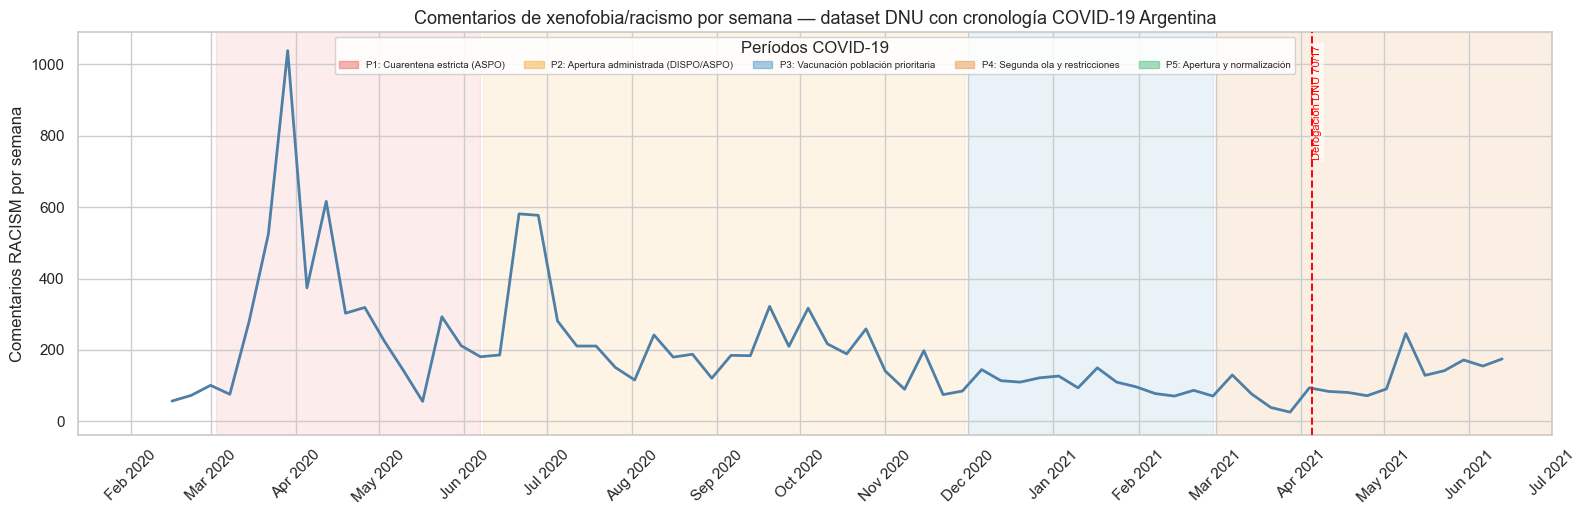

In [15]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── Cargar cronología ─────────────────────────────────────────────────────
xl       = pd.ExcelFile("data/covid_argentina_cronologia_con_periodos.xlsx")
periodos = xl.parse("Periodos")
eventos  = xl.parse("eventos")

def parse_fecha(s):
    s = str(s).strip()
    for fmt in ("%d-%m-%Y", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

eventos["fecha_dt"] = eventos["Fecha"].apply(parse_fecha)
ev3 = eventos[eventos["Nivel"] == 3].dropna(subset=["fecha_dt"])

# ── Serie temporal DNU — cantidad semanal de RACISM ───────────────────────
ts_dnu = (
    dnu_df.set_index("date_tweet")
    .resample("W")["RACISM"]
    .agg(racism_count="sum", n="count")
)
ts_dnu["racism_count"] = ts_dnu["racism_count"].where(ts_dnu["n"] >= 30)

# ── Colores de períodos ───────────────────────────────────────────────────
COLORES_PERIODO = {
    1: ("#e74c3c", 0.10),
    2: ("#f39c12", 0.10),
    3: ("#2980b9", 0.10),
    4: ("#e67e22", 0.12),
    5: ("#27ae60", 0.10),
}

# ── Gráfico ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Sombreado de períodos
periodo_handles = []
for _, row in periodos.iterrows():
    pid = int(row["Periodo"])
    color, alpha = COLORES_PERIODO.get(pid, ("#aaaaaa", 0.10))
    ax.axvspan(row["Fecha inicio"], row["Fecha fin"],
               color=color, alpha=alpha, zorder=0)
    patch = mpatches.Patch(color=color, alpha=0.4,
                           label=f"P{pid}: {row['Nombre del período']}")
    periodo_handles.append(patch)

# Serie DNU — azul apagado
ax.plot(ts_dnu.index, ts_dnu["racism_count"],
        color="#4e7fa6", linewidth=2.0, zorder=5)

# ── Eventos nivel 3: línea roja punteada ─────────────────────────────────
xform = ax.get_xaxis_transform()
for _, ev in ev3.iterrows():
    ax.axvline(ev["fecha_dt"], color="red", linewidth=1.4,
               linestyle="--", zorder=7)
    ax.text(ev["fecha_dt"], 0.97,
            ev["Suceso corto"], fontsize=8, color="red",
            rotation=90, va="top", ha="left",
            transform=xform,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))

# ── Límite temporal: hasta junio 2021 ─────────────────────────────────────
ax.set_xlim(right=pd.Timestamp("2021-07-01"))

# ── Leyenda solo de períodos — arriba al centro ───────────────────────────
ax.legend(handles=periodo_handles, loc="upper center", fontsize=7,
          ncol=5, title="Períodos COVID-19", framealpha=0.85,
          bbox_to_anchor=(0.5, 1.0))

# ── Formato ───────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.set_ylabel("Comentarios RACISM por semana")
ax.set_title("Comentarios de xenofobia/racismo por semana — dataset DNU con cronología COVID-19 Argentina", fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("outputs/dnu_racism_cronologia.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.7B Comentarios con RACISM y CALLS simultáneos

Tweets que combinan **xenofobia/racismo** (`RACISM=1`) con **llamados a la violencia** (`CALLS=1`). Se analiza la serie temporal semanal y la distribución por período COVID-19.

RACISM ∩ CALLS — resumen global
  Total tweets dataset DNU:       1,056,507
  Con RACISM:                       13,493  (1.28%)
  Con CALLS:                         4,527  (0.43%)
  Con RACISM y CALLS (intersec.):    2,519  (0.24%)



,Nombre,Tweets DNU,RACISM,CALLS,RACISM∩CALLS,% sobre DNU,% sobre RACISM
Período,,,,,,,
P1,Cuarentena estricta (ASPO),298219,4607,2297,1127,0.38%,24.5%
P2,Apertura administrada (DISPO/ASPO),460448,5517,1460,924,0.20%,16.7%
P3,Vacunación población prioritaria,126143,1360,346,212,0.17%,15.6%
P4,Segunda ola y restricciones,162190,1727,363,212,0.13%,12.3%
P5,Apertura y normalización,0,0,0,0,-,-


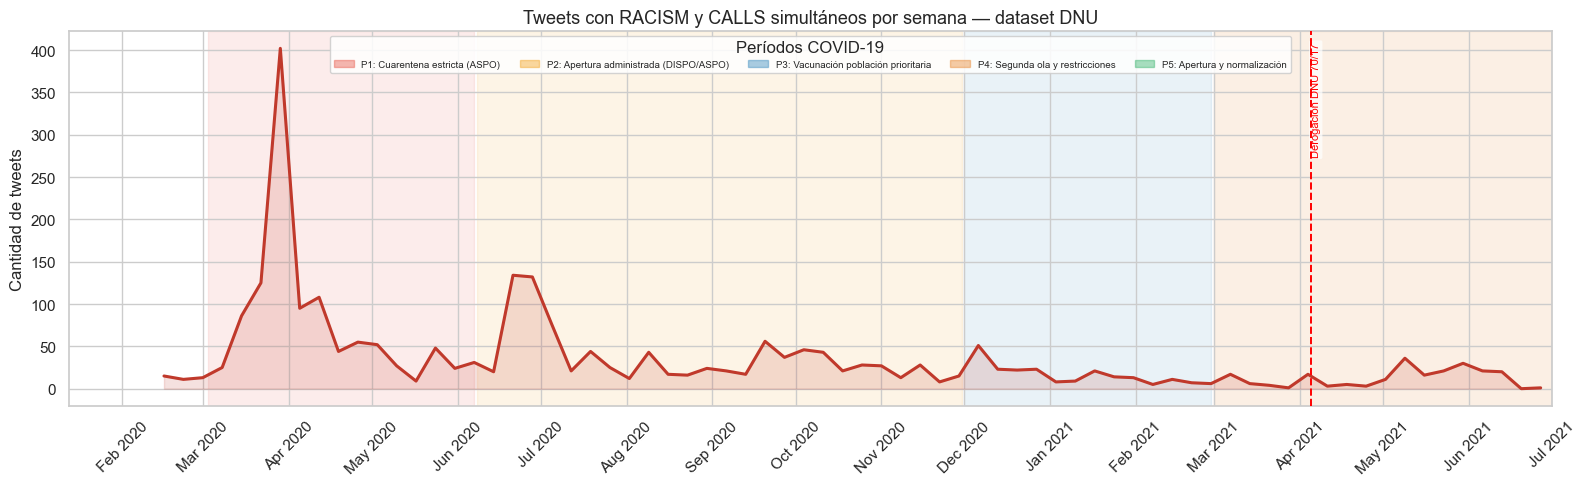

In [16]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── Subconjunto: RACISM=1 y CALLS=1 ──────────────────────────────────────
dnu_rc = dnu_df[(dnu_df["RACISM"] == 1) & (dnu_df["CALLS"] == 1)].copy()

print("=" * 55)
print("RACISM ∩ CALLS — resumen global")
print("=" * 55)
print(f"  Total tweets dataset DNU:       {len(dnu_df):>8,}")
print(f"  Con RACISM:                     {dnu_df['RACISM'].sum():>8,}  ({dnu_df['RACISM'].mean()*100:.2f}%)")
print(f"  Con CALLS:                      {dnu_df['CALLS'].sum():>8,}  ({dnu_df['CALLS'].mean()*100:.2f}%)")
print(f"  Con RACISM y CALLS (intersec.): {len(dnu_rc):>8,}  ({len(dnu_rc)/len(dnu_df)*100:.2f}%)")
print()

# ── Por período ───────────────────────────────────────────────────────────
# Asignar período a cada fila del dataset DNU
def asignar_periodo(fecha):
    for _, row in periodos.iterrows():
        if row["Fecha inicio"] <= fecha <= row["Fecha fin"]:
            return int(row["Periodo"])
    return None

dnu_df["periodo"] = dnu_df["date_tweet"].apply(asignar_periodo)
dnu_rc["periodo"] = dnu_rc["date_tweet"].apply(asignar_periodo)

periodo_nombres = dict(zip(periodos["Periodo"].astype(int), periodos["Nombre del período"]))

resumen_periodos = []
for pid in sorted(periodo_nombres):
    mask = dnu_df["periodo"] == pid
    n_total   = mask.sum()
    n_racism  = dnu_df.loc[mask, "RACISM"].sum()
    n_calls   = dnu_df.loc[mask, "CALLS"].sum()
    n_rc      = ((dnu_df.loc[mask, "RACISM"] == 1) & (dnu_df.loc[mask, "CALLS"] == 1)).sum()
    resumen_periodos.append({
        "Período": f"P{pid}",
        "Nombre": periodo_nombres[pid],
        "Tweets DNU": n_total,
        "RACISM": n_racism,
        "CALLS": n_calls,
        "RACISM∩CALLS": n_rc,
        "% sobre DNU": f"{n_rc/n_total*100:.2f}%" if n_total > 0 else "-",
        "% sobre RACISM": f"{n_rc/n_racism*100:.1f}%" if n_racism > 0 else "-",
    })

display(pd.DataFrame(resumen_periodos).set_index("Período"))

# ── Serie temporal semanal ────────────────────────────────────────────────
ts_rc = (
    dnu_rc.set_index("date_tweet")
    .resample("W")["RACISM"]
    .count()
    .rename("racism_calls")
)

fig, ax = plt.subplots(figsize=(16, 5))

# Sombreado de períodos
periodo_handles = []
for _, row in periodos.iterrows():
    pid = int(row["Periodo"])
    color, alpha = COLORES_PERIODO.get(pid, ("#aaaaaa", 0.10))
    ax.axvspan(row["Fecha inicio"], row["Fecha fin"],
               color=color, alpha=alpha, zorder=0)
    patch = mpatches.Patch(color=color, alpha=0.4,
                           label=f"P{pid}: {row['Nombre del período']}")
    periodo_handles.append(patch)

# Serie
ax.plot(ts_rc.index, ts_rc.values,
        color="#c0392b", linewidth=2.2, zorder=5)
ax.fill_between(ts_rc.index, ts_rc.values,
                alpha=0.15, color="#c0392b", zorder=4)

# Eventos nivel 3
ylim_top = ts_rc.max() * 1.05
for _, ev in ev3.iterrows():
    ax.axvline(ev["fecha_dt"], color="red", linewidth=1.4,
               linestyle="--", zorder=7)
    ax.text(ev["fecha_dt"], ylim_top * 0.97,
            ev["Suceso corto"], fontsize=8, color="red",
            rotation=90, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))

ax.set_xlim(right=pd.Timestamp("2021-07-01"))
ax.legend(handles=periodo_handles, loc="upper center", fontsize=7,
          ncol=5, title="Períodos COVID-19", framealpha=0.85,
          bbox_to_anchor=(0.5, 1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Tweets con RACISM y CALLS simultáneos por semana — dataset DNU", fontsize=13)

plt.tight_layout()
plt.savefig("outputs/dnu_racism_calls_serie.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.8 Noticia más discriminatoria en semanas pico — más de 400 comentarios RACISM

Semanas del gráfico 4.7 donde el dataset DNU superó los 400 comentarios RACISM. Se muestra la noticia que concentró la mayor cantidad de comentarios xenófobos en ese período, con 5 ejemplos.

In [20]:
import html as htmllib
from IPython.display import display, HTML

# ── Helpers (reutilizados en 4.9) ─────────────────────────────────────────
NOMBRES_R = {
    'clarincom': 'Clarín', 'LANACION': 'La Nación', 'infobae': 'Infobae',
    'pagina12': 'Página 12', 'cronica': 'Crónica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}
CATEGORIAS_R = {
    'RACISM':     ('#c0392b', 'Xenofobia/Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio político'),
    'DISABLED':   ('#2471a3', 'Discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges_r(c_row):
    badges = ''.join(
        f'<span style="background:{color};color:white;padding:2px 7px;border-radius:10px;'
        f'font-size:11px;margin-right:3px;">{label}</span>'
        for col, (color, label) in CATEGORIAS_R.items() if c_row.get(col, 0) == 1
    )
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta específica</span>'

def render_nota_racism(nota_row, n_comentarios=5, seed=42):
    tweet_id     = nota_row['tweet_id_noticia']
    medio        = nota_row['medio']
    nombre_medio = NOMBRES_R.get(medio, medio)
    titulo       = htmllib.escape(str(nota_row['title']))
    resumen      = htmllib.escape(str(nota_row['resumen'])[:280])
    n_total      = int(nota_row['n_total'])
    n_racism     = int(nota_row['n_racism'])
    pct          = round(n_racism / n_total * 100, 1) if n_total > 0 else 0
    fecha_str    = dnu_df[dnu_df['tweet_id_noticia'] == tweet_id]['date_tweet'].min().strftime('%d %b %Y')
    url_tweet    = f'https://twitter.com/{medio}/status/{tweet_id}'

    rc = dnu_df[(dnu_df['tweet_id_noticia'] == tweet_id) & (dnu_df['RACISM'] == 1)]
    muestra = rc.sample(min(n_comentarios, len(rc)), random_state=seed)

    comentarios_html = ''
    for _, c in muestra.iterrows():
        texto   = htmllib.escape(str(c['text'])[:300])
        fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
        comentarios_html += (
            f'<div style="margin:8px 0 8px 32px;padding:10px 14px;background:#fff;'
            f'border-left:3px solid #c0392b;border-radius:6px;'
            f'box-shadow:0 1px 3px rgba(0,0,0,0.07);">'
            f'<div style="font-size:11px;color:#999;margin-bottom:5px;">{fecha_c}</div>'
            f'<div style="font-size:13px;color:#222;line-height:1.55;">{texto}</div>'
            f'<div style="margin-top:6px;">{make_badges_r(c)}</div>'
            f'</div>'
        )

    return (
        f'<div style="margin-bottom:28px;">'
        f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:16px 18px;">'
        f'<div style="display:flex;align-items:center;margin-bottom:10px;">'
        f'<div style="width:38px;height:38px;background:#c0392b;border-radius:50%;display:flex;'
        f'align-items:center;justify-content:center;color:white;font-weight:bold;'
        f'font-size:16px;margin-right:10px;flex-shrink:0;">{nombre_medio[0]}</div>'
        f'<div><div style="font-weight:700;font-size:13px;color:#14171a;">{nombre_medio}</div>'
        f'<div style="font-size:11px;color:#657786;">@{medio} · {fecha_str}</div></div>'
        f'<div style="margin-left:auto;display:flex;gap:6px;align-items:center;">'
        f'<span style="background:#c0392b;color:white;font-size:11px;padding:3px 8px;'
        f'border-radius:10px;">{n_racism} RACISM ({pct}%)</span>'
        f'<span style="background:#657786;color:white;font-size:11px;padding:3px 8px;'
        f'border-radius:10px;">{n_total} comentarios</span>'
        f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 8px;'
        f'border-radius:10px;">NOTICIA</span></div></div>'
        f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.4;margin-bottom:8px;">{titulo}</div>'
        f'<div style="font-size:13px;color:#555;line-height:1.55;margin-bottom:10px;">{resumen}</div>'
        f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;font-size:12px;text-decoration:none;">'
        f'Ver tweet original</a></div>'
        f'<div style="margin:6px 0 0 8px;color:#aaa;font-size:11px;">'
        f'Muestra de {len(muestra)} comentarios RACISM (de {n_racism} totales)</div>'
        f'{comentarios_html}</div>'
    )

# ── Semanas con más de 400 comentarios RACISM ─────────────────────────────
dnu_temp = dnu_df.copy()
dnu_temp['semana'] = dnu_temp['date_tweet'].dt.to_period('W')

racism_sem = dnu_temp.groupby('semana')['RACISM'].sum().sort_values(ascending=False)
semanas_pico = racism_sem[racism_sem > 400].index

print(f"Semanas con más de 400 comentarios RACISM: {len(semanas_pico)}")
for s in sorted(semanas_pico):
    print(f"  {s}  →  {racism_sem[s]:,} comentarios RACISM")

# Comentarios de esas semanas
subset = dnu_temp[dnu_temp['semana'].isin(semanas_pico)]

# Noticia con más comentarios RACISM
top_nota = (
    subset.groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .agg(n_total=('text', 'count'), n_racism=('RACISM', 'sum'))
    .reset_index()
    .sort_values('n_racism', ascending=False)
    .iloc[[0]]
    .reset_index(drop=True)
)
display(top_nota[['medio', 'n_total', 'n_racism', 'title']])

# ── Render ────────────────────────────────────────────────────────────────
display(HTML(
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;line-height:1.6;">'
    f'<strong>Semanas con más de 400 comentarios RACISM</strong> — '
    f'noticia con mayor concentración de xenofobia</div>'
    f'{render_nota_racism(top_nota.iloc[0])}</div>'
))

Semanas con más de 400 comentarios RACISM: 5
  2020-03-16/2020-03-22  →  525 comentarios RACISM
  2020-03-23/2020-03-29  →  1,038 comentarios RACISM
  2020-04-06/2020-04-12  →  616 comentarios RACISM
  2020-06-15/2020-06-21  →  581 comentarios RACISM
  2020-06-22/2020-06-28  →  577 comentarios RACISM


,medio,n_total,n_racism,title
0,infobae,359,312,Tres extranjeros incumplían la cuarentena tota...


### 4.9 Noticia más discriminatoria en semanas pico — entre 200 y 400 comentarios RACISM

Mismo análisis que 4.8 para el segundo nivel de actividad: semanas con entre 200 y 400 comentarios RACISM.

In [22]:
# ── Semanas con entre 200 y 400 comentarios RACISM ───────────────────────
semanas_200 = racism_sem[(racism_sem > 200) & (racism_sem <= 400)].index

print(f"Semanas con entre 200 y 400 comentarios RACISM: {len(semanas_200)}")
for s in sorted(semanas_200):
    print(f"  {s}  →  {racism_sem[s]:,} comentarios RACISM")

subset_200 = dnu_temp[dnu_temp['semana'].isin(semanas_200)]

top_nota_200 = (
    subset_200.groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .agg(n_total=('text', 'count'), n_racism=('RACISM', 'sum'))
    .reset_index()
    .sort_values('n_racism', ascending=False)
    .iloc[[0]]
    .reset_index(drop=True)
)
display(top_nota_200[['medio', 'n_total', 'n_racism', 'title']])

# ── Render ────────────────────────────────────────────────────────────────
display(HTML(
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fef9f0;border-left:4px solid #e67e22;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#e67e22;line-height:1.6;">'
    f'<strong>Semanas con entre 200 y 400 comentarios RACISM</strong> — '
    f'noticia con mayor concentración de xenofobia</div>'
    f'{render_nota_racism(top_nota_200.iloc[0])}</div>'
))

Semanas con entre 200 y 400 comentarios RACISM: 17
  2020-03-09/2020-03-15  →  280 comentarios RACISM
  2020-03-30/2020-04-05  →  374 comentarios RACISM
  2020-04-13/2020-04-19  →  303 comentarios RACISM
  2020-04-20/2020-04-26  →  319 comentarios RACISM
  2020-04-27/2020-05-03  →  226 comentarios RACISM
  2020-05-18/2020-05-24  →  293 comentarios RACISM
  2020-05-25/2020-05-31  →  212 comentarios RACISM
  2020-06-29/2020-07-05  →  281 comentarios RACISM
  2020-07-06/2020-07-12  →  211 comentarios RACISM
  2020-07-13/2020-07-19  →  211 comentarios RACISM
  2020-08-03/2020-08-09  →  242 comentarios RACISM
  2020-09-14/2020-09-20  →  322 comentarios RACISM
  2020-09-21/2020-09-27  →  210 comentarios RACISM
  2020-09-28/2020-10-04  →  317 comentarios RACISM
  2020-10-05/2020-10-11  →  217 comentarios RACISM
  2020-10-19/2020-10-25  →  259 comentarios RACISM
  2021-05-03/2021-05-09  →  246 comentarios RACISM


,medio,n_total,n_racism,title
0,clarincom,139,94,Brucelosis en China: se escapó una bacteria de...


### 4.10 Nubes de palabras — comentarios RACISM

Nubes de palabras construidas a partir de los comentarios etiquetados como RACISM en el dataset DNU. Se limpian los textos eliminando stop words del español y expresiones coloquiales del castellano rioplatense. Se genera una nube global y una por período de la pandemia.

Comentarios RACISM en dataset DNU: 13,493

Comentarios RACISM por período:
  P1: Cuarentena estricta (ASPO)          4,607
  P2: Apertura administrada (DISPO/ASPO)  5,517
  P3: Vacunación población prioritaria    1,360
  P4: Segunda ola y restricciones         1,727
  P5: Apertura y normalización                0


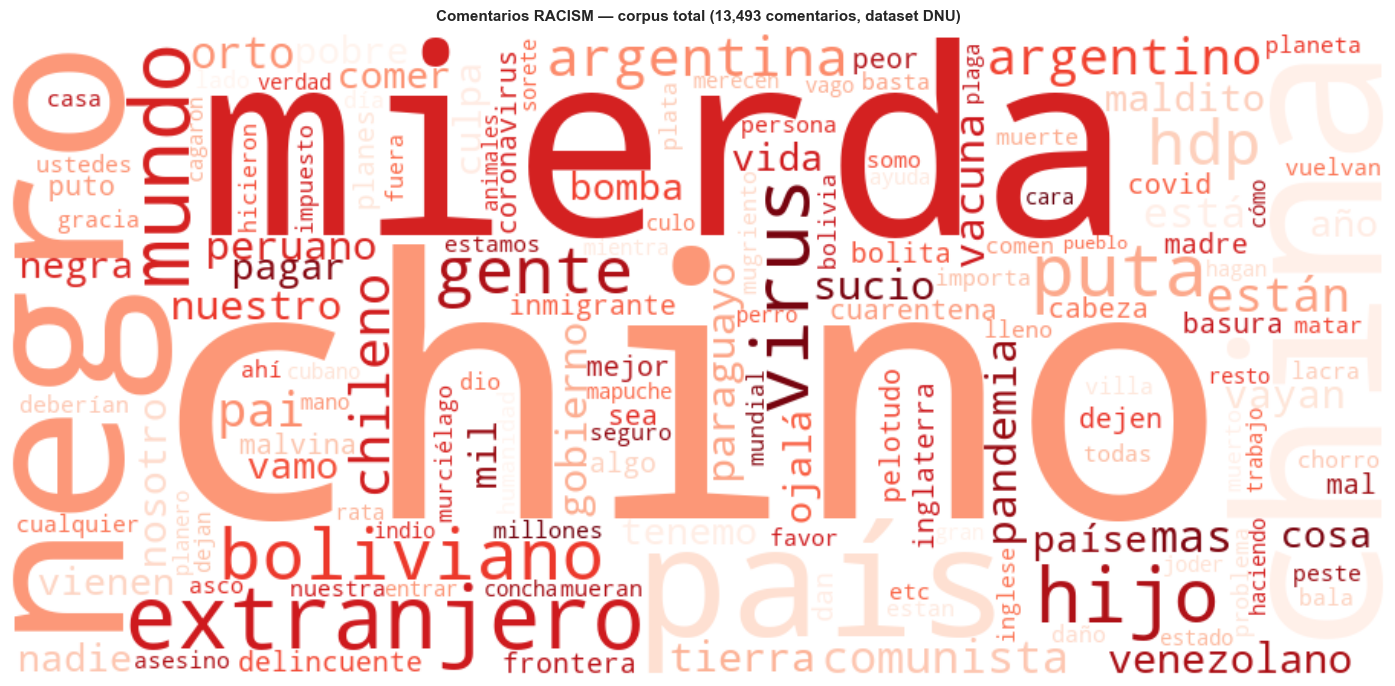

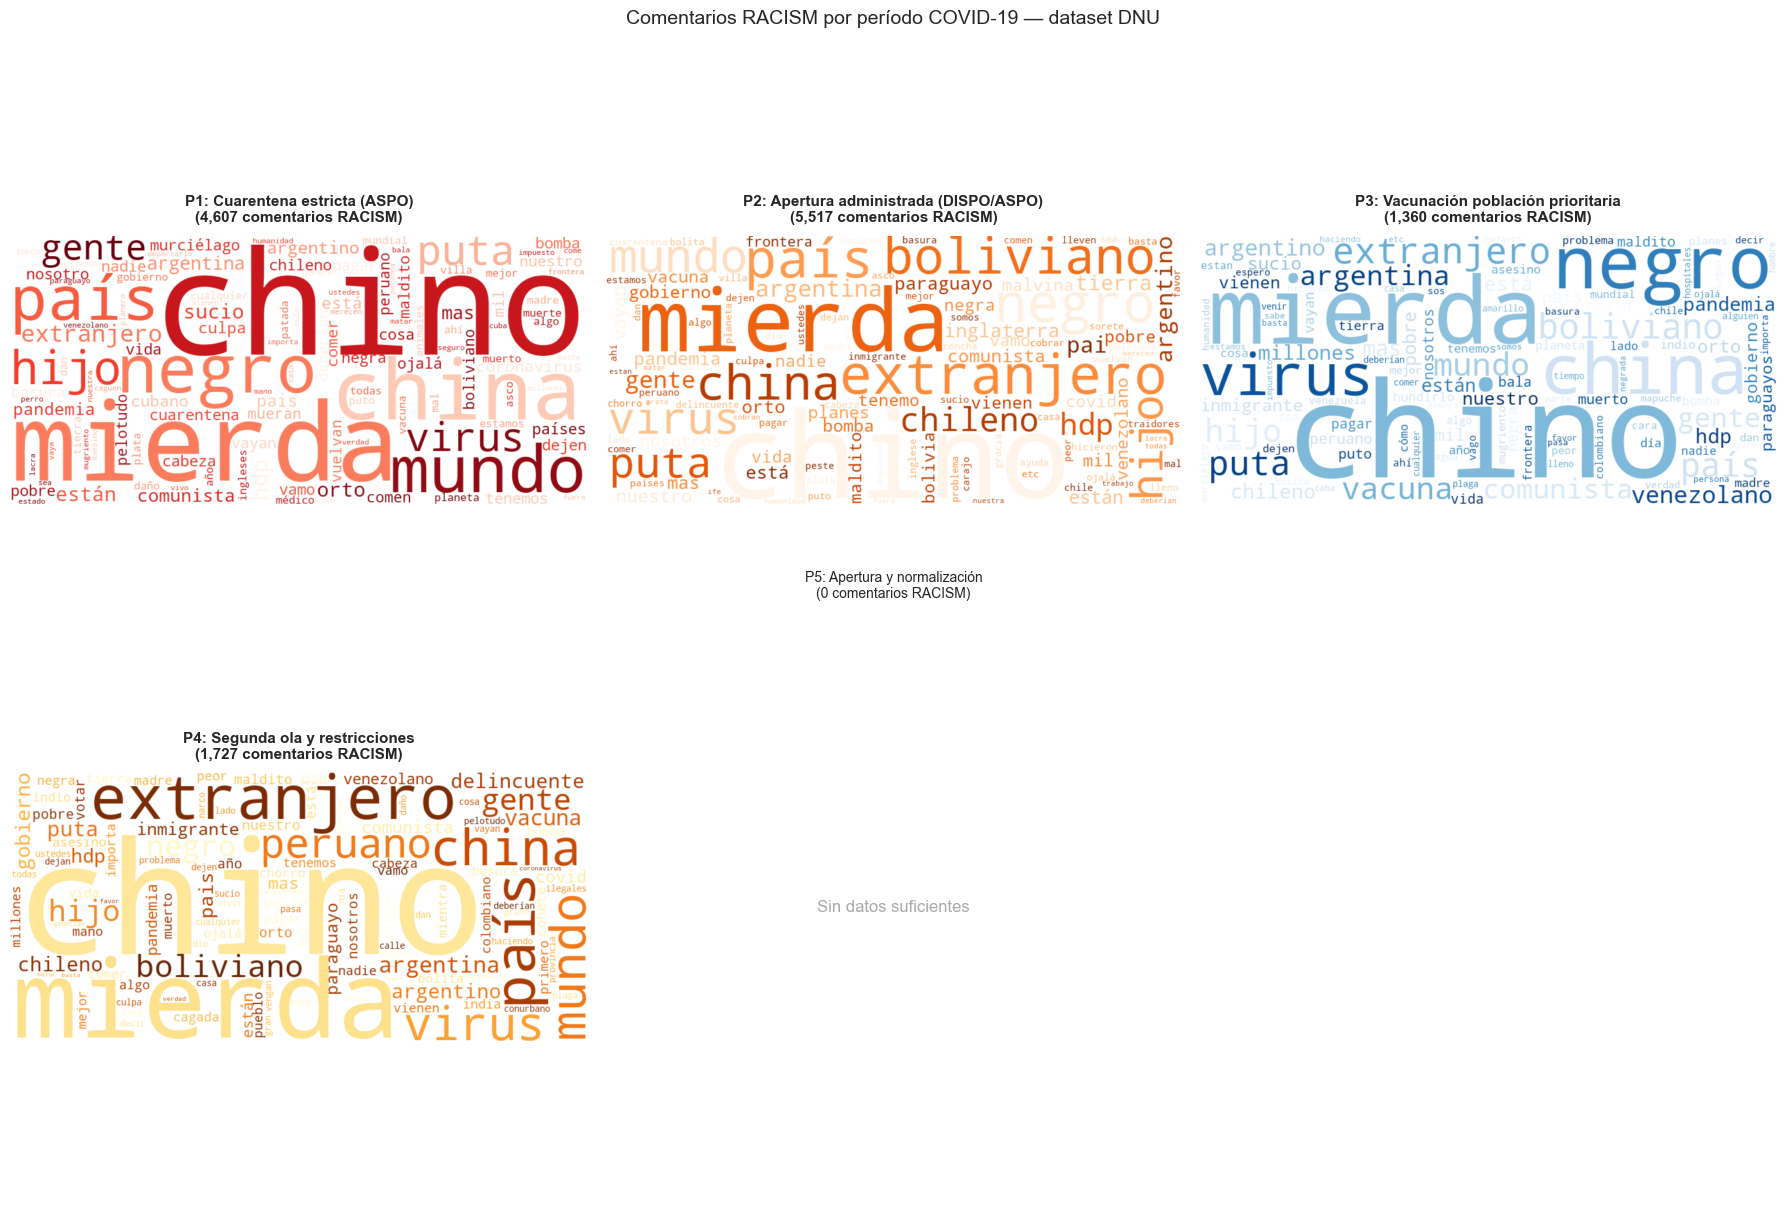

In [23]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'wordcloud'], check=True)
    from wordcloud import WordCloud

import re
import matplotlib.pyplot as plt

# ── Stop words ────────────────────────────────────────────────────────────
STOPWORDS_ALL = {
    # Artículos, preposiciones, conjunciones
    'a', 'al', 'ante', 'bajo', 'con', 'contra', 'de', 'del', 'desde',
    'durante', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre',
    'esa', 'esas', 'ese', 'eso', 'esos', 'esta', 'estas', 'este', 'esto',
    'estos', 'hacia', 'hasta', 'la', 'las', 'le', 'les', 'lo', 'los',
    'me', 'mi', 'mis', 'ni', 'no', 'nos', 'o', 'para', 'pero', 'por',
    'que', 'qué', 'se', 'si', 'sí', 'sin', 'sobre', 'su', 'sus', 'te',
    'tu', 'tú', 'un', 'una', 'uno', 'unas', 'unos', 'ya', 'yo',
    # Verbos auxiliares y comunes
    'ser', 'estar', 'tener', 'hacer', 'poder', 'querer', 'saber', 'ir',
    'fue', 'fueron', 'era', 'eran', 'es', 'son', 'hay', 'hubo', 'han',
    'ha', 'he', 'tiene', 'tienen', 'tengo', 'van', 'va', 'ver', 'hizo',
    'hace', 'hacen', 'iba', 'iban', 'dijo', 'dice', 'deben', 'debe',
    'pueden', 'puede', 'quiere', 'quieren', 'viven', 'vive',
    # Adverbios, determinantes y conectores
    'así', 'bien', 'igual', 'mismo', 'tampoco', 'aunque', 'además',
    'porque', 'cuando', 'donde', 'aquí', 'acá', 'allá', 'allí', 'hoy',
    'ahora', 'antes', 'después', 'siempre', 'nunca', 'cada', 'más',
    'muy', 'nada', 'sino', 'mucho', 'muchos', 'poco', 'tanto', 'tal',
    'vez', 'otro', 'otros', 'otra', 'otras', 'algunas', 'algunos', 'todo',
    'todos', 'toda', 'algún', 'alguna', 'también', 'tan', 'menos', 'casi',
    'solo', 'sólo', 'solo', 'sola', 'mismo', 'misma', 'quien', 'como','quién',
    # Castellano rioplatense / coloquial
    'che', 'vos', 'dale', 're', 'onda', 'tipo', 'loco', 'loca', 'bueno',
    'bue', 'claro', 'capaz', 'obvio', 'posta', 'jaja', 'jajaja',
    'jajajaja', 'jeje', 'jajaj', 'jaj', 'ojo', 'porfa', 'osea', 'pff',
    'uff', 'ugh', 'mmm', 'aca', 'alla', 'ahi', 'igual', 'encima',
    # Artefactos Twitter / medios
    'clarincom', 'lanacion', 'infobae', 'pagina', 'cronica', 'perfilcom',
    'rt', 'via', 'amp', 'co',
}

# ── Limpieza de texto ─────────────────────────────────────────────────────
def limpiar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)          # URLs
    texto = re.sub(r'@\w+', '', texto)                     # menciones
    texto = re.sub(r'#\w+', '', texto)                     # hashtags
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)       # solo letras
    texto = re.sub(r'\b\w{1,2}\b', ' ', texto)            # palabras ≤2 letras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# ── Datos: comentarios RACISM del dataset DNU ─────────────────────────────
racism_df = dnu_df[dnu_df['RACISM'] == 1].copy()
racism_df['texto_limpio'] = racism_df['text'].apply(limpiar)

print(f"Comentarios RACISM en dataset DNU: {len(racism_df):,}")

# ── Cargar y asignar períodos COVID ───────────────────────────────────────
xl = pd.ExcelFile("data/covid_argentina_cronologia_con_periodos.xlsx")
periodos_df = xl.parse("Periodos")
periodos_df['Fecha inicio'] = pd.to_datetime(periodos_df['Fecha inicio'])
periodos_df['Fecha fin']    = pd.to_datetime(periodos_df['Fecha fin'])

racism_df['periodo']       = 0
racism_df['nombre_periodo'] = 'Sin período'
for _, row in periodos_df.iterrows():
    mask = ((racism_df['date_tweet'] >= row['Fecha inicio']) &
            (racism_df['date_tweet'] <= row['Fecha fin']))
    racism_df.loc[mask, 'periodo']       = int(row['Periodo'])
    racism_df.loc[mask, 'nombre_periodo'] = str(row['Nombre del período'])

print("\nComentarios RACISM por período:")
for _, r in periodos_df.iterrows():
    n = (racism_df['periodo'] == int(r['Periodo'])).sum()
    print(f"  P{int(r['Periodo'])}: {r['Nombre del período']:<35} {n:>5,}")

# ── Helper: generar nube ──────────────────────────────────────────────────
def make_wc(corpus, title, ax, colormap='Reds', max_words=120):
    corpus = ' '.join(
        w for w in corpus.split() if w not in STOPWORDS_ALL and len(w) >= 3
    )
    if not corpus.strip():
        ax.text(0.5, 0.5, 'Sin datos suficientes', ha='center', va='center',
                fontsize=12, color='#aaa')
        ax.axis('off')
        ax.set_title(title, fontsize=10, pad=8)
        return
    wc = WordCloud(
        width=900, height=420,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        min_word_length=3,
        collocations=False,
        prefer_horizontal=0.85,
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=11, pad=10, fontweight='bold')
    ax.axis('off')

# ══════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Nube total
# ══════════════════════════════════════════════════════════════════════════
corpus_total = ' '.join(racism_df['texto_limpio'])

fig, ax = plt.subplots(figsize=(15, 7))
make_wc(corpus_total,
        f'Comentarios RACISM — corpus total ({len(racism_df):,} comentarios, dataset DNU)',
        ax, colormap='Reds', max_words=150)
plt.tight_layout()
plt.savefig('outputs/wc_racism_total.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Una nube por período COVID-19
# ══════════════════════════════════════════════════════════════════════════
CMAPS = {1: 'Reds', 2: 'Oranges', 3: 'Blues', 4: 'YlOrBr', 5: 'Greens'}

n = len(periodos_df)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 6))
axes = axes.flatten()

for i, (_, row) in enumerate(periodos_df.iterrows()):
    pid   = int(row['Periodo'])
    nombre = str(row['Nombre del período'])
    n_p   = (racism_df['periodo'] == pid).sum()
    corpus_p = ' '.join(racism_df[racism_df['periodo'] == pid]['texto_limpio'])
    make_wc(corpus_p,
            f'P{pid}: {nombre}\n({n_p:,} comentarios RACISM)',
            axes[i], colormap=CMAPS.get(pid, 'Greys'))

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Comentarios RACISM por período COVID-19 — dataset DNU', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/wc_racism_periodos.png', dpi=150, bbox_inches='tight')
plt.show()